In [4]:
import yfinance as yf
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [5]:
from IPython.display import display

stock = yf.Ticker("AAPL")

df = stock.history(period='1y')

print("--- ML Data Preprocessing ---")

df.drop(['Dividends'], axis=1, inplace=True)
df.drop(['Stock Splits'], axis=1, inplace=True)

# 1. Feature Engineering
# Calculate daily returns
df['Return'] = df['Close'].pct_change()

# Calculate Moving Averages (trend indicators)
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Calculate Volatility (risk indicator)
df['Volatility_20'] = df['Return'].rolling(window=20).std()

# 2. Define Target Variable for ML
# Let's predict if the closing price will go UP (1) or DOWN (0) the next day
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 3. Handle Missing Values
df.dropna(inplace=True)

# Select features
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA_20', 'MA_50', 'Volatility_20']

--- ML Data Preprocessing ---


Scaled Features (Values are now between 0 and 1):


,Open,High,Low,Close,Volume,Return,MA_20,MA_50,Volatility_20
Date,,,,,,,,,
2025-08-04 00:00:00-04:00,0.011229,0.025046,0.000000,0.004164,0.392227,0.542924,0.004527,0.000000,0.154911
2025-08-05 00:00:00-04:00,0.000000,0.000000,0.004804,0.000000,0.179966,0.474455,0.000000,0.000457,0.154232
2025-08-06 00:00:00-04:00,0.022559,0.099002,0.039135,0.100019,0.621080,1.000000,0.001347,0.005724,0.539573
2025-08-07 00:00:00-04:00,0.156594,0.152940,0.149132,0.165666,0.495878,0.810552,0.006213,0.011530,0.640538
2025-08-08 00:00:00-04:00,0.176320,0.253027,0.175855,0.255906,0.657909,0.915264,0.017828,0.020005,0.784523



Target Variable Class Distribution (y):


,Count
Target,
1,107
0,95


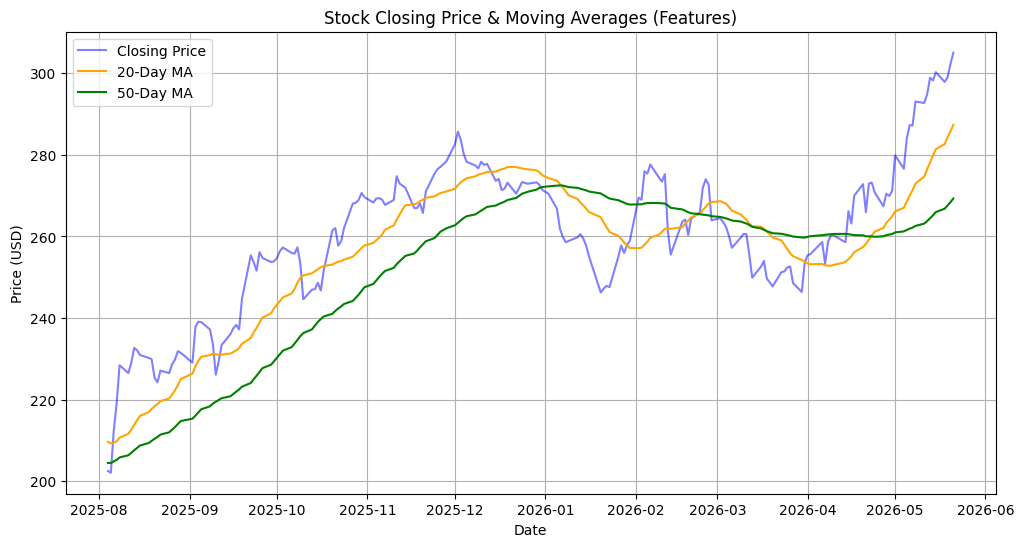

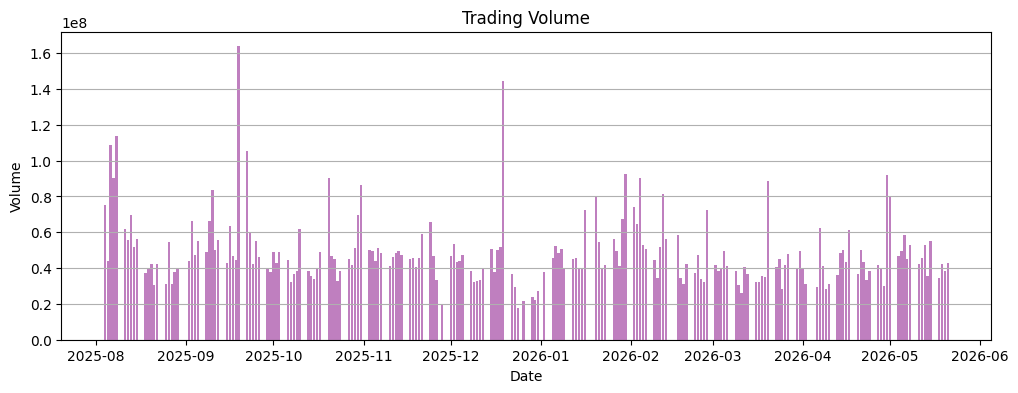

AttributeError: 'builtin_function_or_method' object has no attribute 'index'

<Figure size 1200x600 with 0 Axes>

In [6]:
from torch import q_scale


X = df[features]
y = df['Target']

# 1. Initialize the MinMaxScaler
scaler = MinMaxScaler()

# 2. Fit the scaler to the features and transform them
X_scaled_array = scaler.fit_transform(X)

# 3. Convert the scaled array back into a DataFrame for easier handling and plotting
X = pd.DataFrame(X_scaled_array, columns=features, index=X.index)

print("Scaled Features (Values are now between 0 and 1):")
display(X.head())

# -----

print("\nTarget Variable Class Distribution (y):")
display(y.value_counts().to_frame("Count"))

# Plot 1: Closing Price with Moving Averages
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='Close', label='Closing Price', color='blue', alpha=0.5)
sns.lineplot(data=df, x=df.index, y='MA_20', label='20-Day MA', color='orange')
sns.lineplot(data=df, x=df.index, y='MA_50', label='50-Day MA', color='green')
plt.title('Stock Closing Price & Moving Averages (Features)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Trading Volume (Feature)
plt.figure(figsize=(12, 4))
plt.bar(df.index, df['Volume'], color='purple', alpha=0.5)
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.show()

# Plot the Scaled Volume vs Scaled Close Price to show how they are comparable now
plt.figure(figsize=(12, 6))
plt.plot(q_scale.index, X_scaled['Volume'], label='Scaled Volume', color='purple', alpha=0.6)
plt.plot(X_scaled.index, X_scaled['Close'], label='Scaled Close Price', color='blue', alpha=0.6)

plt.title('Scaled Features: Volume vs Close Price')
plt.xlabel('Date')
plt.ylabel('Scaled Value (0.0 to 1.0)')
plt.legend()
plt.grid(True)
plt.show()